# Kriging on the Branin 2D function (Julia)

This notebook demonstrates basic Gaussian Process (Kriging) regression using **jlibkriging** on the classic 2D Branin test function.

Steps:
1. Setup jlibkriging
2. Define the Branin function and plot it
3. Build a space-filling design and evaluate it
4. Fit a `Kriging` model
5. Predict on a fine grid and plot mean + uncertainty
6. Inspect model parameters

## 0. Setup

Build the C++ core and install the Julia binding (skip if already done).
Requires: `cmake`, a C++ compiler, Julia ≥ 1.10.

```shell
julia -e 'using Pkg; Pkg.develop(path="bindings/Julia/jlibkriging")'
```

In [1]:
using jlibkriging
using Plots
using Random

println("jlibkriging loaded")

jlibkriging loaded


## 1. Branin function

The Branin function is a standard benchmark for surrogate modelling, defined on $[0,1]^2$
(rescaled from its canonical domain $[-5, 10] \times [0, 15]$).
It has three global minima.

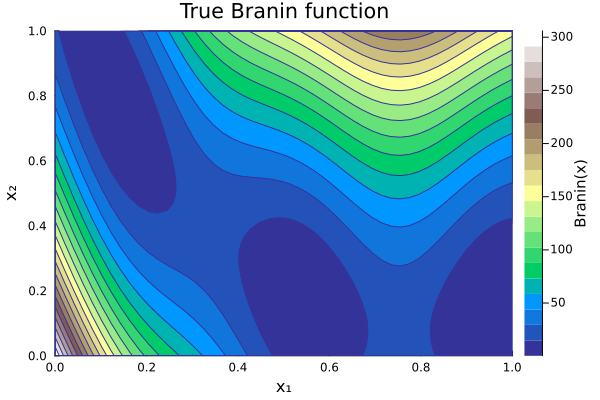

In [2]:
function branin(X::Matrix{Float64})
    x1 = X[:, 1] .* 15 .- 5
    x2 = X[:, 2] .* 15
    return (x2 .- 5 ./ (4π^2) .* x1.^2 .+ 5 ./ π .* x1 .- 6).^2 .+
           10 .* (1 - 1 / (8π)) .* cos.(x1) .+ 10
end

# 50×50 evaluation grid
grid_x = range(0, 1, length=50)
G1 = [x1 for x2 in grid_x, x1 in grid_x]
G2 = [x2 for x2 in grid_x, x1 in grid_x]
grid_pts = hcat(vec(G1), vec(G2))
z_true = reshape(branin(grid_pts), 50, 50)

contourf(collect(grid_x), collect(grid_x), z_true,
         levels=20, color=:terrain, xlabel="x₁", ylabel="x₂",
         title="True Branin function", colorbar_title="Branin(x)")

## 2. Design of experiments

We sample $n = 20$ points using a Latin Hypercube Design.

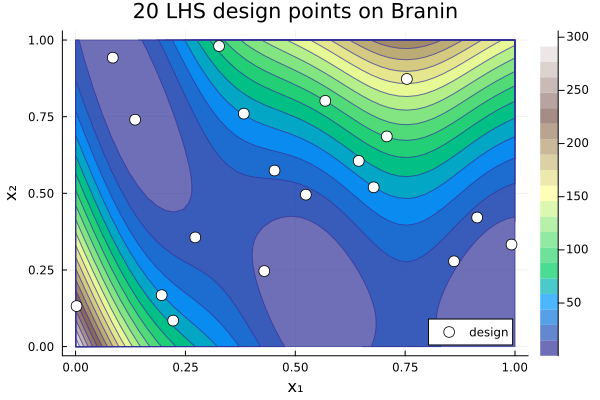

In [3]:
Random.seed!(42)

function lhs(n::Int, d::Int)
    X = zeros(n, d)
    for j in 1:d
        perm = randperm(n)
        X[:, j] = (perm .- rand(n)) ./ n
    end
    return X
end

n = 20
X = lhs(n, 2)
y = branin(X)

p = contourf(collect(grid_x), collect(grid_x), z_true,
             levels=20, color=:terrain, alpha=0.7,
             xlabel="x₁", ylabel="x₂",
             title="$n LHS design points on Branin")
scatter!(p, X[:, 1], X[:, 2],
         mc=:white, msc=:black, ms=6, label="design")

## 3. Fit a Kriging model

`Kriging()` fits by maximum likelihood (`objective = "LL"`).
`optim = "BFGS10"` runs 10 random restarts to avoid local optima.

In [4]:
k = Kriging(y, X, "matern5_2"; optim="BFGS10")
println(jlibkriging.summary(k))

* data: 20x[0.00225604,0.992082],[0.0302394,0.980582] -> 20x[1.08552,238.749]
* trend constant (est.): 818.135
* variance (est.): 737285
* covariance:
  * kernel: matern5_2
  * range (est.): 1.0728, 3.6527
  * fit:
    * objective: LL
    * optim: BFGS10



## 4. Predict on a fine grid

`predict()` returns a named tuple with fields `mean`, `stdev`, `cov`, etc.

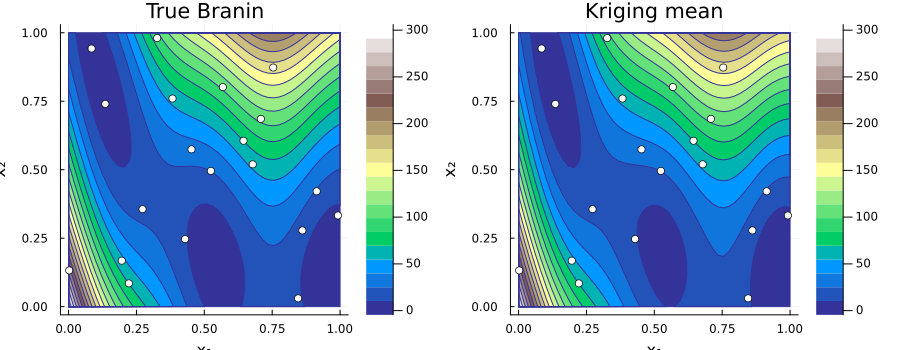

In [5]:
pred   = predict(k, grid_pts; return_stdev=true)
z_mean = reshape(pred.mean, 50, 50)
z_sd   = reshape(pred.stdev, 50, 50)

vmin = min(minimum(z_true), minimum(z_mean))
vmax = max(maximum(z_true), maximum(z_mean))

p1 = contourf(collect(grid_x), collect(grid_x), z_true,
              levels=20, color=:terrain, clims=(vmin, vmax),
              title="True Branin", xlabel="x₁", ylabel="x₂")
scatter!(p1, X[:, 1], X[:, 2], mc=:white, msc=:black, ms=4, label="")

p2 = contourf(collect(grid_x), collect(grid_x), z_mean,
              levels=20, color=:terrain, clims=(vmin, vmax),
              title="Kriging mean", xlabel="x₁", ylabel="x₂")
scatter!(p2, X[:, 1], X[:, 2], mc=:white, msc=:black, ms=4, label="")

plot(p1, p2, layout=(1, 2), size=(900, 350))

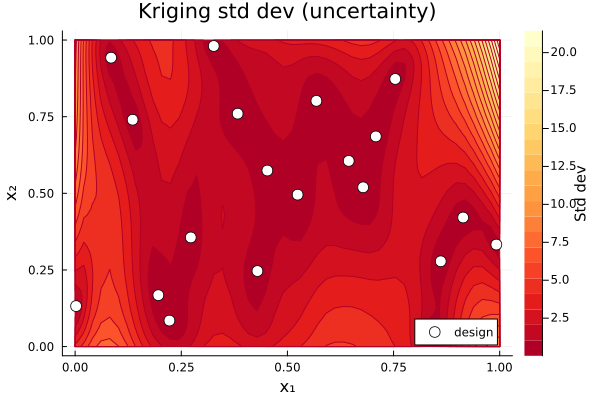

In [6]:
# Posterior standard deviation (uncertainty)
p = contourf(collect(grid_x), collect(grid_x), z_sd,
             levels=20, color=cgrad(:YlOrRd, rev=true),
             title="Kriging std dev (uncertainty)",
             xlabel="x₁", ylabel="x₂", colorbar_title="Std dev")
scatter!(p, X[:, 1], X[:, 2], mc=:white, msc=:black, ms=6, label="design")

## 5. Model inspection

Key fitted parameters: length-scales $\theta$, variance $\sigma^2$, and the log-likelihood at the optimum.

In [7]:
println("Kernel       : ", kernel(k))
println("Theta (range): ", round.(get_theta(k), digits=4))
println("Sigma2       : ", round(get_sigma2(k), digits=4))
println("LogLikelihood: ", round(log_likelihood(k), digits=4))

Kernel       : matern5_2
Theta (range): 

[1.0728, 3.6527]
Sigma2       : 737285.0909
LogLikelihood: -89.8467


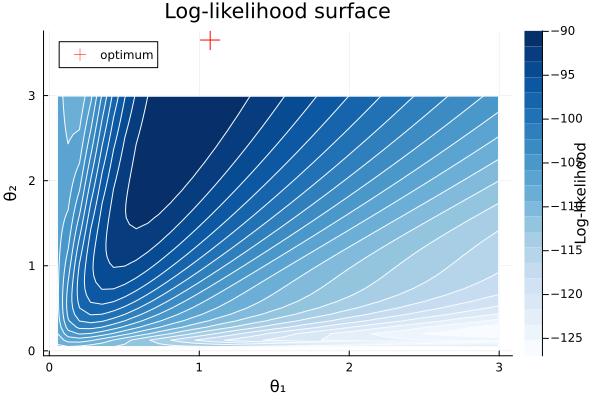

In [8]:
# Log-likelihood surface over (theta1, theta2)
theta_vals = range(0.05, 3.0, length=40)
ll_mat = [log_likelihood_fun(k, [t1, t2]).ll for t2 in theta_vals, t1 in theta_vals]

p = contourf(collect(theta_vals), collect(theta_vals), ll_mat,
             levels=20, color=:Blues,
             title="Log-likelihood surface",
             xlabel="θ₁", ylabel="θ₂", colorbar_title="Log-likelihood")
th = get_theta(k)
scatter!(p, [th[1]], [th[2]], marker=:cross, ms=10, mc=:red, msc=:red,
         label="optimum")